# Phase 4  — Ground Truth & Modeling Strategy

## Question

Can the candidates extracted from the observations be assigned
defensible ground-truth labels?

Before training a supervised model, determine:

1. Origin of the observation data
2. Whether candidate-level labels already exist
3. Whether synthetic/injected signals are present
4. What classes can actually be supported by the available data
5. How labels can be assigned without using the features that
   the model will later be trained to predict from

## 1. Re-examine the Observation and Available Data

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
from blimpy import Waterfall

file_path = "../data/raw/spliced_blc0001020304050607_guppi_57635_35657_Gj144_0005.gpuspec.0002.h5"

obs = Waterfall(file_path)

obs.info()

/Users/majorslammage/Desktop/seti_signal_detection/.venv/lib/python3.14/site-packages/blimpy/__init__.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound



--- File Info ---
DIMENSION_LABELS :   ['frequency' 'feed_id' 'time']
        az_start :                              0.0
       data_type :                                1
            fch1 :                2802.83203125 MHz
            foff :         -0.00286102294921875 MHz
      machine_id :                               20
           nbits :                               32
          nchans :                           351232
            nifs :                                1
     source_name :                            Gj144
         src_dej :                     -9:13:11.007
         src_raj :                       3:32:54.68
    telescope_id :                                6
           tsamp :               1.0737418239999998
   tstart (ISOT) :          2016-09-04T09:54:17.000
    tstart (MJD) :                57635.41269675926
        za_start :                              0.0

Num ints in file :                              273
      File shape :       (273, np.int64(1), 

### Initial Ground-Truth Inspection

The observation header contains metadata describing the telescope
observation, frequency structure, time sampling, and target source.

No explicit candidate labels, signal classifications, RFI annotations,
or injection labels are present in the observation metadata.

Therefore, candidate-level ground truth cannot currently be obtained
directly from the H5 header.

## 2. Investigate Observation Provenance

### Known observation identifiers

- Source name: GJ 144
- Observation start: 2016-09-04 09:54:17 UTC
- MJD: 57635.41269675926
- Frequency range: 1797.952–2802.832 MHz
- Number of frequency channels: 351,232
- Number of time integrations: 273

### Ground-truth question

Determine whether this observation has any associated candidate labels,
RFI classifications, injected-signal labels, ON/OFF observations, or
published analysis products that could provide defensible ground truth.

### Observation provenance confirmed

The H5 observation was matched to a Breakthrough Listen archive entry
using its target, MJD, timestamp, and coordinates.

- Target: GJ 144
- Telescope: Green Bank Telescope (GBT)
- Observation start: 2016-09-04 09:54:17 UTC
- MJD: 57635.4127
- RA: ~53.2278 degrees
- Dec: ~-9.2197 degrees
- Archive format: HDF5
- Archive status: Ungraded

The archive metadata therefore confirms the provenance of the local
observation. However, the archive entry does not currently provide a
ground-truth candidate classification.

In [4]:
file_path = "../data/raw/spliced_blc0001020304050607_guppi_57635_35657_Gj144_0005.gpuspec.0000.h5"

obs = Waterfall(file_path)

obs.info()

blimpy.io.base_reader WARNING  Selection size is 21.44 GB, which exceeds the memory usage limit of 7.8639678955078125 GB. Keeping data on disk.

--- File Info ---
DIMENSION_LABELS :   ['frequency' 'feed_id' 'time']
        az_start :                              0.0
       data_type :                                1
            fch1 :                2802.83203125 MHz
            foff :      -2.7939677238464355e-06 MHz
      machine_id :                               20
           nbits :                               32
          nchans :                        359661568
            nifs :                                1
     source_name :                            Gj144
         src_dej :                     -9:13:11.007
         src_raj :                       3:32:54.68
    telescope_id :                                6
           tsamp :                     18.253611008
   tstart (ISOT) :          2016-09-04T09:54:17.000
    tstart (MJD) :                57635.41269675926
     

In [5]:
candidate_freq = 2188.43  # MHz
window_mhz = 0.05         # +/- 0.05 MHz = 100 kHz total

f_start = candidate_freq - window_mhz
f_stop = candidate_freq + window_mhz

obs_candidate = Waterfall(
    file_path,
    f_start=f_start,
    f_stop=f_stop
)

freqs_highres, data_highres = obs_candidate.grab_data()

print(freqs_highres.shape)
print(data_highres.shape)
print(freqs_highres[:5])

(35791,)
(16, 35791)
[2188.47999964 2188.47999685 2188.47999405 2188.47999126 2188.47998846]


In [6]:
plt.figure(figsize=(12, 6))

plt.imshow(
    data_highres,
    aspect="auto",
    origin="lower",
    extent=[
        freqs_highres[-1],
        freqs_highres[0],
        0,
        data_highres.shape[0]
    ]
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Time integration")
plt.title("High-Resolution Candidate Region")

plt.show()
plt.close('all')

/var/folders/96/b9ghc6nj60952p_5_s5gk7980000gn/T/ipykernel_72660/3063485890.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [7]:
print("Min:", np.min(data_highres))
print("Median:", np.median(data_highres))
print("Mean:", np.mean(data_highres))
print("Max:", np.max(data_highres))

print("1st percentile:", np.percentile(data_highres, 1))
print("99th percentile:", np.percentile(data_highres, 99))

Min: 1.4796022e+11
Median: 3.6506796e+11
Mean: 1.0985965e+13
Max: 3.3429588e+16
1st percentile: 2.0227572e+11
99th percentile: 7.9883774e+13


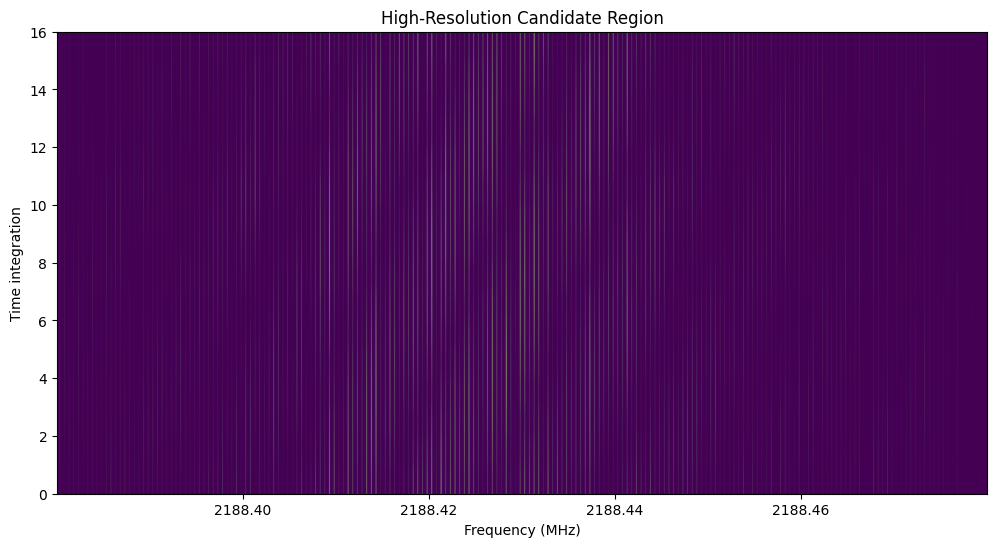

In [84]:
vmin = np.percentile(data_highres, 1)
vmax = np.percentile(data_highres, 99)

plt.figure(figsize=(12, 6))

plt.imshow(
    data_highres,
    aspect="auto",
    origin="lower",
    extent=[
        freqs_highres[-1],
        freqs_highres[0],
        0,
        data_highres.shape[0]
    ],
    vmin=vmin,
    vmax=vmax
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Time integration")
plt.title("High-Resolution Candidate Region")

plt.show()

In [9]:
mean_spectrum = np.mean(data_highres, axis=0)

max_index = np.argmax(mean_spectrum)
max_freq = freqs_highres[max_index]

print("Strongest mean frequency:", max_freq)
print("Mean power:", mean_spectrum[max_index])

Strongest mean frequency: 2188.422703742981
Mean power: 8.744399e+15


In [10]:
from scipy.signal import find_peaks

mean_spectrum = np.mean(data_highres, axis=0)

peaks, properties = find_peaks(
    mean_spectrum,
    prominence=np.std(mean_spectrum) * 3
)

peak_freqs_highres = freqs_highres[peaks]

print("Number of peaks:", len(peak_freqs_highres))
print(peak_freqs_highres[:20])

Number of peaks: 76
[2188.45970426 2188.45870402 2188.45670354 2188.45620342 2188.45420573
 2188.45370561 2188.45270257 2188.45220525 2188.45170513 2188.45070489
 2188.45020477 2188.44870441 2188.44820429 2188.44770417 2188.44720405
 2188.44670393 2188.44620381 2188.44570369 2188.44520357 2188.44420332]


In [11]:
peaks

array([ 7264,  7622,  8338,  8517,  9232,  9411,  9770,  9948, 10127,
       10485, 10664, 11201, 11380, 11559, 11738, 11917, 12096, 12275,
       12454, 12812, 12991, 13170, 13349, 13528, 13706, 13886, 14064,
       14243, 14422, 14780, 14960, 15138, 15317, 15496, 15675, 15854,
       16034, 16212, 16391, 16570, 16749, 16928, 17107, 17285, 17464,
       17823, 18001, 18180, 18360, 18538, 18718, 18896, 19254, 19433,
       19612, 19791, 19970, 20149, 20328, 20507, 20865, 21044, 21223,
       21402, 21581, 21759, 21939, 22118, 22296, 22655, 22834, 23013,
       23370, 23728, 24444, 25338])

In [12]:
peak_spacings_hz = np.abs(np.diff(peak_freqs_highres)) * 1e6

print("First spacings (Hz):")
print(peak_spacings_hz[:20])

First spacings (Hz):
[1000.24044514 2000.48089027  500.12022257 1997.68692255  500.12022257
 1003.03441286  497.32625484  500.12022257 1000.24044514  500.12022257
 1500.36066771  500.12022257  500.12022257  500.12022257  500.12022257
  500.12022257  500.12022257  500.12022257 1000.24044514  500.12022257]


High-resolution inspection resolves the previously identified candidate region into numerous narrow spectral components. Detected spectral peaks show approximately 500 Hz fundamental spacing, with larger separations occurring near integer multiples of 500 Hz. This is consistent with comb-like spectral structure and motivates investigation of instrumental or terrestrial RFI as a possible origin.

In [13]:
comparison_freq = 2300.0
window_mhz = 0.05

comparison_obs = Waterfall(
    file_path,
    f_start=comparison_freq - window_mhz,
    f_stop=comparison_freq + window_mhz
)

comparison_freqs, comparison_data = comparison_obs.grab_data()

print(comparison_freqs.shape)
print(comparison_data.shape)

(35792,)
(16, 35792)


In [14]:
comparison_mean_spectrum = np.mean(comparison_data, axis=0)

comparison_peaks, _ = find_peaks(
    comparison_mean_spectrum,
    prominence=np.std(comparison_mean_spectrum) * 3
)

comparison_peak_freqs = comparison_freqs[comparison_peaks]

comparison_spacings_hz = (
    np.abs(np.diff(comparison_peak_freqs)) * 1e6
)

print("Number of peaks:", len(comparison_peak_freqs))
print("First peak frequencies:")
print(comparison_peak_freqs[:20])

print("\nFirst spacings (Hz):")
print(comparison_spacings_hz[:20])

Number of peaks: 1699
First peak frequencies:
[2300.04995372 2300.04992019 2300.04983637 2300.04980285 2300.04972462
 2300.0495933  2300.04957933 2300.04951227 2300.04942846 2300.04935581
 2300.04932787 2300.04928876 2300.04923847 2300.04914068 2300.04909597
 2300.04901495 2300.04895069 2300.04890878 2300.04889481 2300.04879422]

First spacings (Hz):
[ 33.52761269  83.81903172  33.52761269  78.23109627 131.31648302
  13.96983862  67.05522537  83.81903172  72.64316082  27.93967724
  39.11554813  50.29141903  97.78887033  44.70348358  81.02506399
  64.26125765  41.90951586  13.96983862 100.58283806  30.73364496]


In [15]:
def analyze_peak_spacing(freqs, data):
    mean_spectrum = np.mean(data, axis=0)

    peaks, _ = find_peaks(
        mean_spectrum,
        prominence=np.std(mean_spectrum) * 3
    )

    peak_freqs = freqs[peaks]

    spacings_hz = (
        np.abs(np.diff(peak_freqs)) * 1e6
    )

    return peak_freqs, spacings_hz

comparison_obs = Waterfall(
    file_path,
    f_start=comparison_freq - window_mhz,
    f_stop=comparison_freq + window_mhz
)

comparison_freqs, comparison_data = comparison_obs.grab_data()

# peak_freqs, spacings_hz = analyze_peak_spacing(
#     comparison_freqs,
#     comparison_data
# )

# print("Number of peaks:", len(peak_freqs))
# print(spacings_hz[:20])

In [16]:
comparison_centers = [1900.0, 2100.0, 2500.0, 2700.0]
window_mhz = 0.05

for center_freq in comparison_centers:
    comparison_obs = Waterfall(
        file_path,
        f_start=center_freq - window_mhz,
        f_stop=center_freq + window_mhz
    )

    comparison_freqs, comparison_data = comparison_obs.grab_data()

    comparison_mean_spectrum = np.mean(comparison_data, axis=0)

    comparison_peaks, _ = find_peaks(
        comparison_mean_spectrum,
        prominence=np.std(comparison_mean_spectrum) * 3
    )

    comparison_peak_freqs = comparison_freqs[comparison_peaks]

    comparison_spacings_hz = (
        np.abs(np.diff(comparison_peak_freqs)) * 1e6
    )

    print(f"\n--- {center_freq} MHz ---")
    print("Number of peaks:", len(comparison_peak_freqs))
    print("First spacings (Hz):")
    print(comparison_spacings_hz[:20])
    rounded_spacings = np.round(comparison_spacings_hz)
    values, counts = np.unique(
    rounded_spacings,
    return_counts=True
)
    print(values, counts)




--- 1900.0 MHz ---
Number of peaks: 43
First spacings (Hz):
[ 514.09006119 6579.79398966  667.758286    818.63254309 1271.25531435
 1947.39550352 2807.93756247 1237.72770166 3330.40952682  435.85896492
 2279.87766266 1092.44138002 1262.87341118 2833.08327198 2380.46050072
 1053.32583189 3436.58030033 2282.67163038 1159.4966054  1212.58199215]
[  28.   31.  341.  436.  514.  668.  819. 1053. 1092. 1112. 1159. 1213.
 1238. 1263. 1271. 1274. 1394. 1403. 1905. 1947. 1981. 2087. 2218. 2280.
 2283. 2380. 2590. 2677. 2685. 2693. 2808. 2833. 3129. 3330. 3437. 4761.
 5191. 5733. 6524. 6580. 6775.] [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1]

--- 2100.0 MHz ---
Number of peaks: 74
First spacings (Hz):
[2042.39040613 1098.02931547  220.72345018  108.96474123  961.124897
 1785.34537554 1380.22005558 1413.74766827  989.06457424  226.31138563
 1751.81776285  840.98428488  583.93925428 1310.37086248 1181.84834719
  209.54757929  282.19074011  307.33644962  80

In [17]:
# 2188 Mhz candidiate

# want to determine nearest multiple of 500
nearest_500_multiple = np.round(peak_spacings_hz / 500) * 500
spacing_error_hz = np.abs(
    peak_spacings_hz - nearest_500_multiple
)
print(spacing_error_hz[:20])

[0.24044514 0.48089027 0.12022257 2.31307745 0.12022257 3.03441286
 2.67374516 0.12022257 0.24044514 0.12022257 0.36066771 0.12022257
 0.12022257 0.12022257 0.12022257 0.12022257 0.12022257 0.12022257
 0.24044514 0.12022257]


In [18]:
print("Number of spacings:", len(spacing_error_hz))
print("Mean error:", np.mean(spacing_error_hz))
print("Median error:", np.median(spacing_error_hz))
print("Maximum error:", np.max(spacing_error_hz))

Number of spacings: 75
Mean error: 0.948185920715332
Median error: 0.12022256851196289
Maximum error: 3.0344128608703613


In [19]:
comparison_centers = [1900.0, 2100.0, 2500.0, 2700.0]
window_mhz = 0.05

for center_freq in comparison_centers:
    comparison_obs = Waterfall(
        file_path,
        f_start=center_freq - window_mhz,
        f_stop=center_freq + window_mhz
    )

    comparison_freqs, comparison_data = comparison_obs.grab_data()

    comparison_mean_spectrum = np.mean(comparison_data, axis=0)

    comparison_peaks, _ = find_peaks(
        comparison_mean_spectrum,
        prominence=np.std(comparison_mean_spectrum) * 3
    )

    comparison_peak_freqs = comparison_freqs[comparison_peaks]

    comparison_spacings_hz = (
        np.abs(np.diff(comparison_peak_freqs)) * 1e6
    )

    print(f"\n--- {center_freq} MHz ---")
    print("Number of peaks:", len(comparison_peak_freqs))
    print("First spacings (Hz):")
    print(comparison_spacings_hz[:20])
    nearest_500_multiple = np.round(comparison_spacings_hz / 500) * 500
    spacing_error_hz = np.abs(
    comparison_spacings_hz - nearest_500_multiple
    )
    print("Number of spacings:", len(spacing_error_hz))
    print("Mean error:", np.mean(spacing_error_hz))
    print("Median error:", np.median(spacing_error_hz))
    print("Maximum error:", np.max(spacing_error_hz))




--- 1900.0 MHz ---
Number of peaks: 43
First spacings (Hz):
[ 514.09006119 6579.79398966  667.758286    818.63254309 1271.25531435
 1947.39550352 2807.93756247 1237.72770166 3330.40952682  435.85896492
 2279.87766266 1092.44138002 1262.87341118 2833.08327198 2380.46050072
 1053.32583189 3436.58030033 2282.67163038 1159.4966054  1212.58199215]
Number of spacings: 42
Mean error: 140.28564379328773
Median error: 159.3162715435028
Maximum error: 239.07899856567383

--- 2100.0 MHz ---
Number of peaks: 74
First spacings (Hz):
[2042.39040613 1098.02931547  220.72345018  108.96474123  961.124897
 1785.34537554 1380.22005558 1413.74766827  989.06457424  226.31138563
 1751.81776285  840.98428488  583.93925428 1310.37086248 1181.84834719
  209.54757929  282.19074011  307.33644962  801.86873674 1695.93840837]
Number of spacings: 73
Mean error: 130.8230112676751
Median error: 140.2994990348816
Maximum error: 248.1822371482849

--- 2500.0 MHz ---
Number of peaks: 2
First spacings (Hz):
[27.93967724

In [20]:
plt.figure(figsize=(12, 6))

plt.plot(
    freqs_highres,
    mean_spectrum
)

plt.scatter(
    peak_freqs_highres,
    mean_spectrum[peaks],
    marker="x"
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Mean Power")
plt.title("2188 MHz High-Resolution Spectrum with Detected Peaks")

plt.show()
plt.close('all')

/var/folders/96/b9ghc6nj60952p_5_s5gk7980000gn/T/ipykernel_72660/1326999121.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [21]:
plt.figure(figsize=(12, 6))

plt.plot(
    freqs_highres,
    mean_spectrum
)

plt.scatter(
    peak_freqs_highres,
    mean_spectrum[peaks],
    marker="x"
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Mean Power")
plt.title("2188 MHz High-Resolution Spectrum with Detected Peaks")

plt.xlim(2188.425, 2188.430)
plt.show()
plt.close('all')

/var/folders/96/b9ghc6nj60952p_5_s5gk7980000gn/T/ipykernel_72660/2230037078.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


The prominent lines are landing at roughly 0.0005 MHz intervals.<br><br>

1 MHz = 1,000,000 Hz
<br>
0.0005 × 1,000,000<br>
= 500 Hz

The 2188.43-MHz candidate resolves into numerous narrow spectral peaks. Their neighboring separations frequently lie extremely close to integer multiples of approximately 500 Hz. Comparison windows elsewhere in the observation do not show the same degree of alignment to a 500-Hz grid. Visual inspection of the high-resolution spectrum supports the numerical spacing result.

## 4. Frequency Extent of the Comb-Like Structure

In [22]:
# Checking to see how far this comb structure extends over our window
# stretching frequency both left and right
plt.figure(figsize=(12, 6))

plt.plot(
    freqs_highres,
    mean_spectrum
)

plt.scatter(
    peak_freqs_highres,
    mean_spectrum[peaks],
    marker="x"
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Mean Power")
plt.title("2188 MHz High-Resolution Spectrum with Detected Peaks")

plt.xlim(2188.420, 2188.440)

plt.show()
plt.close("all")

/var/folders/96/b9ghc6nj60952p_5_s5gk7980000gn/T/ipykernel_72660/3434207477.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [23]:
# Extending a little further to 2188.415 and 2188.445
plt.figure(figsize=(12, 6))

plt.plot(
    freqs_highres,
    mean_spectrum
)

plt.scatter(
    peak_freqs_highres,
    mean_spectrum[peaks],
    marker="x"
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Mean Power")
plt.title("2188 MHz High-Resolution Spectrum with Detected Peaks")

plt.xlim(2188.415, 2188.445)

plt.show()
plt.close("all")


/var/folders/96/b9ghc6nj60952p_5_s5gk7980000gn/T/ipykernel_72660/1448112832.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [24]:
frequency_mask = (peak_freqs_highres>= 2188.415) & (peak_freqs_highres <= 2188.445)

peak_freqs_highres_30khz_window = peak_freqs_highres[frequency_mask]

print(peak_freqs_highres_30khz_window)

[2188.44420332 2188.4437032  2188.44320308 2188.44270296 2188.44220284
 2188.44170552 2188.4412026  2188.44070528 2188.44020516 2188.43970504
 2188.4387048  2188.43820188 2188.43770456 2188.43720444 2188.43670432
 2188.4362042  2188.43570407 2188.43520116 2188.43470383 2188.43420371
 2188.43370359 2188.43320347 2188.43270335 2188.43220323 2188.43170591
 2188.43120579 2188.43020275 2188.42970543 2188.42920531 2188.42870239
 2188.42820507 2188.42770215 2188.42720482 2188.42620458 2188.42570446
 2188.42520434 2188.42470422 2188.4242041  2188.42370398 2188.42320386
 2188.42270374 2188.4217035  2188.42120338 2188.42070326 2188.42020314
 2188.41970302 2188.4192057  2188.41870278 2188.41820266 2188.41770533
 2188.4167023  2188.41620218 2188.41570206]


In [25]:
peak_freqs_highres_30khz_window_spacings_hz = (
        np.abs(np.diff(peak_freqs_highres_30khz_window)) * 1e6
    )

print(peak_freqs_highres_30khz_window_spacings_hz)

[ 500.12022257  500.12022257  500.12022257  500.12022257  497.32625484
  502.91419029  497.32625484  500.12022257  500.12022257 1000.24044514
  502.91419029  497.32625484  500.12022257  500.12022257  500.12022257
  500.12022257  502.91419029  497.32625484  500.12022257  500.12022257
  500.12022257  500.12022257  500.12022257  497.32625484  500.12022257
 1003.03441286  497.32625484  500.12022257  502.91419029  497.32625484
  502.91419029  497.32625484 1000.24044514  500.12022257  500.12022257
  500.12022257  500.12022257  500.12022257  500.12022257  500.12022257
 1000.24044514  500.12022257  500.12022257  500.12022257  500.12022257
  497.32625484  502.91419029  500.12022257  497.32625484 1003.03441286
  500.12022257  500.12022257]


In [26]:
# extending outward further

frequency_mask = (peak_freqs_highres>= 2188.400) & (peak_freqs_highres <= 2188.600)

peak_freqs_highres_200khz_window = peak_freqs_highres[frequency_mask]

peak_freqs_highres_200khz_window_spacings_hz = (
        np.abs(np.diff(peak_freqs_highres_200khz_window)) * 1e6
    )

print(peak_freqs_highres_200khz_window_spacings_hz)

[1000.24044514 2000.48089027  500.12022257 1997.68692255  500.12022257
 1003.03441286  497.32625484  500.12022257 1000.24044514  500.12022257
 1500.36066771  500.12022257  500.12022257  500.12022257  500.12022257
  500.12022257  500.12022257  500.12022257 1000.24044514  500.12022257
  500.12022257  500.12022257  500.12022257  497.32625484  502.91419029
  497.32625484  500.12022257  500.12022257 1000.24044514  502.91419029
  497.32625484  500.12022257  500.12022257  500.12022257  500.12022257
  502.91419029  497.32625484  500.12022257  500.12022257  500.12022257
  500.12022257  500.12022257  497.32625484  500.12022257 1003.03441286
  497.32625484  500.12022257  502.91419029  497.32625484  502.91419029
  497.32625484 1000.24044514  500.12022257  500.12022257  500.12022257
  500.12022257  500.12022257  500.12022257  500.12022257 1000.24044514
  500.12022257  500.12022257  500.12022257  500.12022257  497.32625484
  502.91419029  500.12022257  497.32625484 1003.03441286  500.12022257
  500.

In [27]:
print(np.min(freqs_highres))
print(np.max(freqs_highres))

2188.3800035342574
2188.479999639094


Current mask stopped at 2188.479 therefore, larger file needed to be loaded in because tail end of mask is not grabbing any information 

In [28]:
larger_comparison_freq_start = 2188.0
larger_comparison_freq_stop = 2200.0

larger_comparison_obs = Waterfall(
    file_path,
    f_start=larger_comparison_freq_start,
    f_stop=larger_comparison_freq_stop
)

larger_comparison_freqs, larger_comparison_data = (
    larger_comparison_obs.grab_data()
)

print(larger_comparison_freqs.shape)
print(larger_comparison_data.shape)

large_window_mean_spectrum = np.mean(
    larger_comparison_data,
    axis=0
)

large_window_peaks, _ = find_peaks(
    large_window_mean_spectrum,
    prominence=np.std(large_window_mean_spectrum) * 3
)

large_window_peak_freqs_highres = (
    larger_comparison_freqs[large_window_peaks]
)

print("Number of peaks:", len(large_window_peak_freqs_highres))
print(large_window_peak_freqs_highres[:20])

(4294968,)
(16, 4294968)
Number of peaks: 432
[2197.8515625  2197.19524272 2197.19386809 2197.19336797 2197.19305504
 2197.19292931 2197.19274212 2197.19242919 2197.19211627 2197.19024431
 2197.189367   2197.18868248 2197.18849249 2197.1879309  2197.18711786
 2197.1868664  2197.18661774 2197.18624335 2197.18599189 2197.18593042]


In [29]:
large_window_freq_spacings_hz = (
        np.abs(np.diff(large_window_peak_freqs_highres)) * 1e6
    )

print(large_window_freq_spacings_hz)

[6.56319782e+05 1.37463212e+03 5.00120223e+02 3.12924385e+02
 1.25728548e+02 1.87195837e+02 3.12924385e+02 3.12924385e+02
 1.87195837e+03 8.77305865e+02 6.84522092e+02 1.89989805e+02
 5.61587512e+02 8.13044608e+02 2.51457095e+02 2.48663127e+02
 3.74391675e+02 2.51457095e+02 6.14672899e+01 1.31316483e+03
 1.87195837e+02 6.87316060e+02 5.00120223e+02 3.74391675e+02
 6.14672899e+01 1.56462193e+03 1.87195837e+02 1.87195837e+02
 2.48663127e+02 5.64381480e+02 1.25728548e+02 6.14672899e+01
 6.14672899e+01 1.25728548e+02 1.62608922e+03 1.87195837e+02
 5.00120223e+02 6.14672899e+01 3.12924385e+02 1.93621963e+03
 3.77185643e+02 2.48663127e+02 6.14672899e+01 1.25728548e+02
 1.87475234e+03 4.38652933e+02 4.35858965e+02 2.51457095e+02
 1.25728548e+02 6.14672899e+01 3.12924385e+02 3.12924385e+02
 3.10130417e+02 1.89989805e+02 8.10250640e+02 6.42612576e+01
 4.38652933e+02 3.10130417e+02 2.51457095e+02 1.87195837e+02
 1.66763272e+06 3.07336450e+01 2.79396772e+01 9.72300768e+02
 5.77328727e+05 1.347807

In [30]:
for i in range(len(large_window_freq_spacings_hz)):
    print(
        large_window_peak_freqs_highres[i],
        "->",
        large_window_peak_freqs_highres[i + 1],
        ":",
        large_window_freq_spacings_hz[i],
        "Hz"
    )

2197.8515625 -> 2197.195242717862 : 656319.7821378708 Hz
2197.195242717862 -> 2197.193868085742 : 1374.6321201324463 Hz
2197.193868085742 -> 2197.1933679655194 : 500.12022256851196 Hz
2197.1933679655194 -> 2197.1930550411344 : 312.9243850708008 Hz
2197.1930550411344 -> 2197.192929312587 : 125.7285475730896 Hz
2197.192929312587 -> 2197.1927421167493 : 187.19583749771118 Hz
2197.1927421167493 -> 2197.192429192364 : 312.9243850708008 Hz
2197.192429192364 -> 2197.192116267979 : 312.9243850708008 Hz
2197.192116267979 -> 2197.190244309604 : 1871.9583749771118 Hz
2197.190244309604 -> 2197.189367003739 : 877.3058652877808 Hz
2197.189367003739 -> 2197.1886824816465 : 684.5220923423767 Hz
2197.1886824816465 -> 2197.1884924918413 : 189.98980522155762 Hz
2197.1884924918413 -> 2197.187930904329 : 561.5875124931335 Hz
2197.187930904329 -> 2197.187117859721 : 813.0446076393127 Hz
2197.187117859721 -> 2197.186866402626 : 251.4570951461792 Hz
2197.186866402626 -> 2197.1866177394986 : 248.66312742233276

The Phase 3 candidate sits inside a broader comb-like spectral structure. The main continuous region extends approximately from 2188.383 to 2188.483 MHz, so roughly 100 kHz wide. Within that region, prominent peaks repeatedly occur near 500 Hz spacing and integer multiples of 500 Hz. The wider scan also revealed recurring ~28–31 Hz separations inside parts of that structure, suggesting possible finer substructure that we have not yet interpreted.

# TEMPORAL ANALYSIS

#### Frequency Behavior

In [31]:
freqs_highres, data_highres

(array([2188.47999964, 2188.47999685, 2188.47999405, ..., 2188.38000912,
        2188.38000633, 2188.38000353], shape=(35791,)),
 array([[3.2009391e+11, 3.1649769e+11, 3.4853647e+11, ..., 3.6354071e+11,
         3.3531429e+11, 3.2310614e+11],
        [2.9509966e+11, 3.2254742e+11, 3.1836094e+11, ..., 3.2605975e+11,
         3.0451030e+11, 3.0313660e+11],
        [3.3982218e+11, 3.4445525e+11, 4.0318734e+11, ..., 3.3247746e+11,
         2.6639316e+11, 3.6414957e+11],
        ...,
        [2.0226628e+11, 2.4718536e+11, 2.3888296e+11, ..., 2.3378477e+11,
         2.3017465e+11, 2.3065541e+11],
        [2.2101135e+11, 2.2356948e+11, 2.2212313e+11, ..., 2.6519170e+11,
         2.2144103e+11, 2.5637803e+11],
        [2.5399188e+11, 1.9502553e+11, 2.0024592e+11, ..., 2.6309951e+11,
         2.3408851e+11, 2.1469554e+11]], shape=(16, 35791), dtype=float32))

In [32]:
temp_max_indices = np.argmax(data_highres, axis=1)
temporal_max = np.max(data_highres, axis=1)

#temp_max_index = np.argmax(temp_max_indices)
temporal_freqs = freqs_highres[temp_max_indices]
print(temporal_freqs)

[2188.43170591 2188.43170591 2188.43170591 2188.43170591 2188.43970504
 2188.43970504 2188.44570369 2188.42270374 2188.42270374 2188.42270374
 2188.42870239 2188.42870239 2188.42870239 2188.43820188 2188.43820188
 2188.42270095]


In [33]:
print(len(temp_max_indices))

16


In [34]:
tsamp = obs_candidate.header['tsamp']
tsamp_array = np.arange(len(temp_max_indices)) * tsamp

In [35]:
print(tsamp_array)

[  0.          18.25361101  36.50722202  54.76083302  73.01444403
  91.26805504 109.52166605 127.77527706 146.02888806 164.28249907
 182.53611008 200.78972109 219.0433321  237.2969431  255.55055411
 273.80416512]


In [36]:
plt.figure(figsize=(12, 6))

plt.plot(
    tsamp_array,
    temporal_freqs
)


plt.xlabel("Time")
plt.ylabel("Frequency (MHz)")
plt.title("Time vs Frequency")

plt.show()
plt.close('all')

/var/folders/96/b9ghc6nj60952p_5_s5gk7980000gn/T/ipykernel_72660/4160129870.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [37]:
candidate_freq = 2188.43
tracking_window = 0.00005  # MHz = 50 Hz

tracking_mask = (
    (freqs_highres >= candidate_freq - tracking_window) &
    (freqs_highres <= candidate_freq + tracking_window)
)

candidate_freqs = freqs_highres[tracking_mask]
candidate_data = data_highres[:, tracking_mask]

candidate_max_indices = np.argmax(candidate_data, axis=1)
candidate_temporal_freqs = candidate_freqs[candidate_max_indices]

In [38]:
print(candidate_temporal_freqs)

[2188.43000717 2188.43000717 2188.42999041 2188.43000717 2188.43004629
 2188.43003232 2188.43002394 2188.43004908 2188.43002394 2188.43004908
 2188.42996527 2188.42998482 2188.4300435  2188.43002114 2188.43003232
 2188.43004629]


In [39]:
plt.figure(figsize=(12, 6))

plt.plot(tsamp_array, candidate_temporal_freqs, marker='o')

plt.xlabel("Time (s)")
plt.ylabel("Frequency (MHz)")
plt.title("Candidate Frequency vs Time")

plt.show()
plt.close('all')

/var/folders/96/b9ghc6nj60952p_5_s5gk7980000gn/T/ipykernel_72660/27897987.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [40]:
drift_slope, intercept = np.polyfit(tsamp_array, candidate_temporal_freqs, 1)

#convert to Hz
drift_slope_hz = drift_slope * 1e6
print("Drift rate:", drift_slope_hz, "Hz/s")

Drift rate: 0.06955400849662846 Hz/s


In [41]:
predicted_freqs = drift_slope * tsamp_array + intercept

residuals = candidate_temporal_freqs - predicted_freqs

# residual sum of squares
ss_res = np.sum(residuals ** 2)

candidate_mean_freq = np.mean(candidate_temporal_freqs)

# total sum of squares
ss_tot = np.sum((candidate_temporal_freqs - candidate_mean_freq) ** 2 )

candidate_drift_r2 = 1 - (ss_res / ss_tot)
print(candidate_drift_r2)

0.05733785368310884


The tracked feature near 2188.43 MHz varies in frequency over the observation. A linear fit yields a small positive slope of approximately +0.070 Hz/s, but the fit is poor (R² ≈ 0.057). Visual inspection shows irregular frequency variation rather than a coherent linear trend; fitting increasingly flexible polynomial models would risk overfitting the limited 16-sample time series.

#### Power over Time

How does candidate's strength change across those 16 time integrations

In [42]:
candidate_power = np.max(candidate_data, axis=1)
print(candidate_power)

[8.5868682e+11 8.8150501e+11 5.9787687e+11 6.2666854e+11 8.2977056e+11
 9.6118237e+11 1.0436278e+12 1.2532668e+12 9.2933240e+11 8.1260315e+11
 6.9559150e+11 4.7071750e+11 5.3193255e+11 6.4396277e+11 6.6294913e+11
 7.0597444e+11]


In [43]:
plt.figure(figsize=(12, 6))

plt.plot(tsamp_array, candidate_power, marker='o')

plt.xlabel("Time (s)")
plt.ylabel("Power")
plt.title("Candidate Power vs Time")

plt.show()
plt.close('all')

/var/folders/96/b9ghc6nj60952p_5_s5gk7980000gn/T/ipykernel_72660/4073369402.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [44]:
candidate_mean_power = np.mean(candidate_power)
candidate_std_power = np.std(candidate_power)

print(f'Candidate Power mean: {candidate_mean_power}, Candidate Power STD: {candidate_std_power}')

Candidate Power mean: 781603045376.0, Candidate Power STD: 198003523584.0


In [45]:
candidate_CV = candidate_std_power / candidate_mean_power
print(f'Candidate CV: {candidate_CV}')

Candidate CV: 0.2533300220966339


In [46]:
candidate_max_power = np.max(candidate_power)
candidate_min_power = np.min(candidate_power)
candidate_power_range = candidate_max_power - candidate_min_power

In [47]:
print(f'Max: {candidate_max_power}, Min : {candidate_min_power}, Range: {candidate_power_range}')

Max: 1253266817024.0, Min : 470717497344.0, Range: 782549319680.0


In [48]:
# Does power change as time passes?
# x = time — the independent variable
# y = power — the thing we’re measuring as time changes

power_slope, power_intercept = np.polyfit(tsamp_array, candidate_power, 1)

print(power_slope)

-832705923.4302335


In [49]:
predicted_power = power_slope * tsamp_array + power_intercept

power_residuals = candidate_power - predicted_power

# residual sum of squares
ss_res = np.sum(power_residuals ** 2)

candidate_mean_power = np.mean(candidate_power)

# total sum of squares
ss_tot = np.sum((candidate_power - candidate_mean_power) ** 2 )

candidate_power_r2 = 1 - (ss_res / ss_tot)
print(candidate_power_r2)

0.12522591286450757


The candidate’s power varies meaningfully over time, but the variation is not well described by a linear trend. The low R² of 0.125 indicates that a straight-line model explains only about 12.5% of the observed power variation. Visual inspection suggests some temporal structure, particularly a rise followed by a decline, but we have not established a specific nonlinear model for that structure.

## Persistence

We want to determine where our candidate power is over our 3 std threshold, how ofter in remains above that threshold, and whether it occurs continuously or intermittenly over time

In [50]:
print(freqs_highres.shape)
print(data_highres.shape)

(35791,)
(16, 35791)


In [51]:
freq_spacing = np.abs(freqs_highres[1] - freqs_highres[0])

print(freq_spacing)

2.7939677238464355e-06


In [52]:
# Mhz to Hz
freq_spacing_hz = freq_spacing * 1e6
print(freq_spacing_hz)

2.7939677238464355


In [53]:
# Choose neighborhood roughly 50 bins on each side
bin_neighborhood = 50 * freq_spacing_hz
print(bin_neighborhood)

139.69838619232178


In [54]:
# Spacing in Mhz, relation to original units in dataset
freq_range_p = bin_neighborhood / 1e6
print(freq_range_p)

0.00013969838619232178


In [55]:
# Defining max_freq 
max_power_per_freq = np.max(data_highres, axis=0)
max_idx = np.argmax(max_power_per_freq)

max_freq_p = freqs_highres[max_idx]
print(max_freq_p)

2188.431705906987


In [56]:
# Boolean mask defining local neighborhood
#freq_range_p = 0.1 

lower_f_p = max_freq_p - freq_range_p
upper_f_p = max_freq_p + freq_range_p

freq_mask_p = (freqs_highres >= lower_f_p) & (freqs_highres <= upper_f_p)

print(freq_mask_p.shape)
print(sum(freq_mask_p))

(35791,)
101


In [57]:
local_data_p = data_highres[:,freq_mask_p]
print(local_data_p.shape)


(16, 101)


In [58]:
candidate_power_p = data_highres[:, max_idx]

In [59]:
local_mean_p = np.mean(local_data_p, axis=1)
local_std_p = np.std(local_data_p, axis=1)

temporal_z_p = (candidate_power_p - local_mean_p) / local_std_p

print(temporal_z_p.shape)


(16,)


In [60]:
print(temporal_z_p)

[ 9.99618     9.995698    9.978256    9.850417    9.165359    6.8193316
  3.610702    1.2918373   0.31761467 -0.01606118 -0.06899286  0.06616326
  0.31065753  0.55757695  0.6380397   0.40001237]


In [61]:
temporal_z_mask_p = temporal_z_p >= 3

temporal_z_true_p = np.sum(temporal_z_mask_p)

persistence_p = temporal_z_true_p / len(temporal_z_p)
print(persistence_p)

0.4375


In [62]:
# Run Length
current_run = 0
run_lengths = []

for b_value in temporal_z_mask_p:
    if b_value:
        current_run += 1
    else:
        if current_run:
            run_lengths.append(current_run)
            current_run = 0

if current_run:
    run_lengths.append(current_run)

print(run_lengths)
print(len(run_lengths))
print(max(run_lengths))

[7]
1
7


In [63]:
times_p = np.arange(data_highres.shape[0]) * tsamp
print(times_p)

[  0.          18.25361101  36.50722202  54.76083302  73.01444403
  91.26805504 109.52166605 127.77527706 146.02888806 164.28249907
 182.53611008 200.78972109 219.0433321  237.2969431  255.55055411
 273.80416512]


In [64]:
max_run_duration = max(run_lengths) * tsamp
print(max_run_duration)

127.775277056


For your actual candidate:<br><br>

* Persistence = 7/16 = 43.75%<br>
* Run lengths = [7]<br>
* Number of runs = 1<br>
* Longest run = 7 samples (~127.8 s)<br>
* Qualitatively: low intermittency<br>

In [65]:
if run_lengths:
    intermittency = len(run_lengths) / sum(temporal_z_mask_p)
else:
    intermittency = np.nan

In [66]:
print(intermittency)

0.14285714285714285


1. Local background definition — ±50 frequency bins around the candidate.
2. Temporal z-score — candidate power relative to local background at each time sample.
3. Persistence — fraction of time samples with z \ge 3.
4. Run length — consecutive above-threshold detections.
5. Intermittency — fragmentation of those detections.

* persistence = 0.4375
* detections = 7/16
* run lengths = [7]
* longest run = 7 samples ≈ 127.8 s
* intermittency ≈ 0.143

Based on our results, the candidate persists above the 3σ threshold for 43.75% of the observation and these detections occur in one continuous 7 sample run. This run results in low intermittency explaing the run is concentrated rathen than broken  

In [67]:
plt.figure(figsize=(14, 6))

plt.scatter(
    times_p,
    temporal_z_p
)

plt.axhline(
    y=3,
    color='r',
    linestyle='--',
    linewidth=2,
    label='3σ Threshold'
)

plt.xlabel("Time (s)")
plt.ylabel("Z-score")
plt.title("Candidate Significance Over Time")

plt.legend()
plt.show()
plt.close("all")

/var/folders/96/b9ghc6nj60952p_5_s5gk7980000gn/T/ipykernel_72660/893882466.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


# Drift-Aware Persistence

### Follow candidate peak frequency through time

In [68]:
tracked_candidate_power = candidate_data[
    np.arange(candidate_data.shape[0]),
    candidate_max_indices
]

In [69]:
print(tracked_candidate_power.shape)
print(tracked_candidate_power)

(16,)
[8.5868682e+11 8.8150501e+11 5.9787687e+11 6.2666854e+11 8.2977056e+11
 9.6118237e+11 1.0436278e+12 1.2532668e+12 9.2933240e+11 8.1260315e+11
 6.9559150e+11 4.7071750e+11 5.3193255e+11 6.4396277e+11 6.6294913e+11
 7.0597444e+11]


In [70]:
tracked_means = []
tracked_stds = []

for i in range(candidate_data.shape[0]):
    peak_idx = candidate_max_indices[i]

    lower_idx = max(0, peak_idx - 50)
    upper_idx = min(candidate_data.shape[1], peak_idx + 51)

    local_region = candidate_data[i, lower_idx:upper_idx]

    tracked_means.append(np.mean(local_region))
    tracked_stds.append(np.std(local_region))

print(tracked_means)
print(len(tracked_means), len(tracked_stds))

[np.float32(5.9024756e+11), np.float32(4.9142104e+11), np.float32(4.9854697e+11), np.float32(5.2463432e+11), np.float32(6.4338126e+11), np.float32(7.5069915e+11), np.float32(8.211756e+11), np.float32(8.424372e+11), np.float32(6.9059884e+11), np.float32(6.3843775e+11), np.float32(5.0703293e+11), np.float32(3.7507642e+11), np.float32(3.9381932e+11), np.float32(4.7140084e+11), np.float32(5.3854667e+11), np.float32(5.3639987e+11)]
16 16


In [71]:
tracked_means = np.array(tracked_means) 
tracked_stds = np.array(tracked_stds)

In [72]:
tracked_z_score = (tracked_candidate_power - tracked_means) / tracked_stds

print(len(tracked_z_score))

16


In [73]:
tracked_z_score

array([3.0127692, 4.779303 , 2.0491526, 1.6822394, 2.3079655, 2.471644 ,
       1.8782458, 3.5090916, 2.8416603, 2.1580603, 3.2347329, 2.8442574,
       2.9253228, 2.5878868, 2.052752 , 2.2822754], dtype=float32)

In [74]:
tracked_means = []
tracked_stds = []

for i in range(candidate_data.shape[0]):
    peak_idx = candidate_max_indices[i]

    lower_idx = max(0, peak_idx - 50)
    upper_idx = min(candidate_data.shape[1], peak_idx + 51)

    left_background  = candidate_data[i, lower_idx:peak_idx - 2]
    right_background = candidate_data[i, peak_idx + 3:upper_idx]

    local_background = np.concatenate([
    left_background,
    right_background
        ])

    tracked_means.append(np.mean(local_background))
    tracked_stds.append(np.std(local_background))


tracked_means = np.array(tracked_means)
tracked_stds = np.array(tracked_stds)


tracked_z_score = (tracked_candidate_power - tracked_means) / tracked_stds

print(len(tracked_z_score))

16


In [75]:
print(tracked_z_score)

[3.3890884 7.9428487 2.4379396 1.6574231 2.407014  3.1283154 2.0518334
 3.8340106 3.2540398 2.3274307 3.9355593 3.3672228 3.5450313 2.861177
 2.2698336 2.479958 ]


In [76]:
# Persistence 
tracked_z_mask = tracked_z_score >= 3

tracked_z_true = np.sum(tracked_z_mask)

persistence_p = tracked_z_true / len(tracked_z_mask)
print(persistence_p)

0.5


In [77]:
# Run Length
current_run = 0
run_lengths = []

for b_value in tracked_z_mask:
    if b_value:
        current_run += 1
    else:
        if current_run:
            run_lengths.append(current_run)
            current_run = 0

if current_run:
    run_lengths.append(current_run)

print(run_lengths)
print(len(run_lengths))
print(max(run_lengths))

[2, 1, 2, 3]
4
3


In [78]:
longest_run_p = max(run_lengths) * tsamp
print(longest_run_p)

54.760833024


In [79]:
# Intermittency 
if run_lengths:
    intermittency_tracked = len(run_lengths) / sum(tracked_z_mask)
else:
    intermittency_tracked = np.nan

In [80]:
print(intermittency_tracked)

0.5


So the tracked-frequency picture is now:

* persistence = 50%
* run lengths = [2, 1, 2, 3]
* longest run = 3 samples
* intermittency = 0.5

In [81]:
plt.figure(figsize=(14, 6))

plt.scatter(
    times_p,
    temporal_z_p,
    color='red',
        label='Fixed Frequency'
)

plt.scatter(
    times_p,
    tracked_z_score,
    color='black',
    label='Tracked Frequency'
)

plt.axhline(
    y=3,
    color='r',
    linestyle='--',
    linewidth=2,
    label='3σ Threshold'
)

plt.xlabel("Time (s)")
plt.ylabel("Z-score")
plt.title("Fixed vs. Tracked Candidate Significance Over Time")

plt.legend()
plt.show()
plt.close("all")

/var/folders/96/b9ghc6nj60952p_5_s5gk7980000gn/T/ipykernel_72660/3214517612.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Fixed vs. tracked frequency persistence

Fixed frequency analysis deteced the candidate above our 3 std threshold in 7/6 time samples, corresponding to a persistence of 43.75%. The seven detections were consecutive within a single run and intermittency if 0.143. When the peak frequency was tracked independently and local background was recalculated with a ±2-bin guard band, 8/16 samples exceeded the 3\sigma threshold, increasing persistence to 50%.

The comparison shows the temporal behavior depends on how the candidate is followed through frequency. Fixed, the candidate appears strong and continuous then receeds below the threshold, while the tracked frequency show a more fragmentated pattern. [2,1,2,3]. This result does not itself establish Doppler drift but demonstrates why we should consider frequency movemnt when measuring temporal persistence. 

In [82]:
candidate_features = {
    # Frequency structure
    "candidate_frequency_mhz": max_freq_p,
    "comb_spacing_hz": 500,
    "analysis_window_mhz": 0.05,

    # Frequency behavior over time
    "drift_rate_hz_s": drift_slope_hz,
    "drift_r2": candidate_drift_r2,

    # Power behavior over time
    "power_cv": candidate_CV,
    "power_slope": power_slope,
    "power_trend_r2": candidate_power_r2,

    # Temporal detection behavior
    "tracked_persistence": 0.50,
    "num_detection_runs": len(run_lengths),
    "longest_run_samples": max(run_lengths),
    "longest_run_seconds": longest_run_p,
    "intermittency": len(run_lengths) / np.sum(tracked_z_mask)
}

candidate_features

{'candidate_frequency_mhz': np.float64(2188.431705906987),
 'comb_spacing_hz': 500,
 'analysis_window_mhz': 0.05,
 'drift_rate_hz_s': np.float64(0.06955400849662846),
 'drift_r2': np.float64(0.05733785368310884),
 'power_cv': np.float32(0.25333002),
 'power_slope': np.float64(-832705923.4302335),
 'power_trend_r2': np.float64(0.12522591286450757),
 'tracked_persistence': 0.5,
 'num_detection_runs': 4,
 'longest_run_samples': 3,
 'longest_run_seconds': np.float64(54.760833024),
 'intermittency': np.float64(0.5)}

The candidate near 2188.43 Mhz shows interesting characteristcs. It roughly shows a 500 Hz comb like structure, variable power, and intermittent detections. The fitted linear frequency and power trends both have low R^2 values, showing linear models do not explain much of its behavior. 

The candidate is interesting enough to further investigate but not enough evidence to determine its origin. The comb like structure could be consistent with man made structures. More context and comparison would be appropriate before drawing a stronger conclusion. 